# Fitting coherent T1/T2 decay
Run cells in order. Configure paths and switches in cell 1.

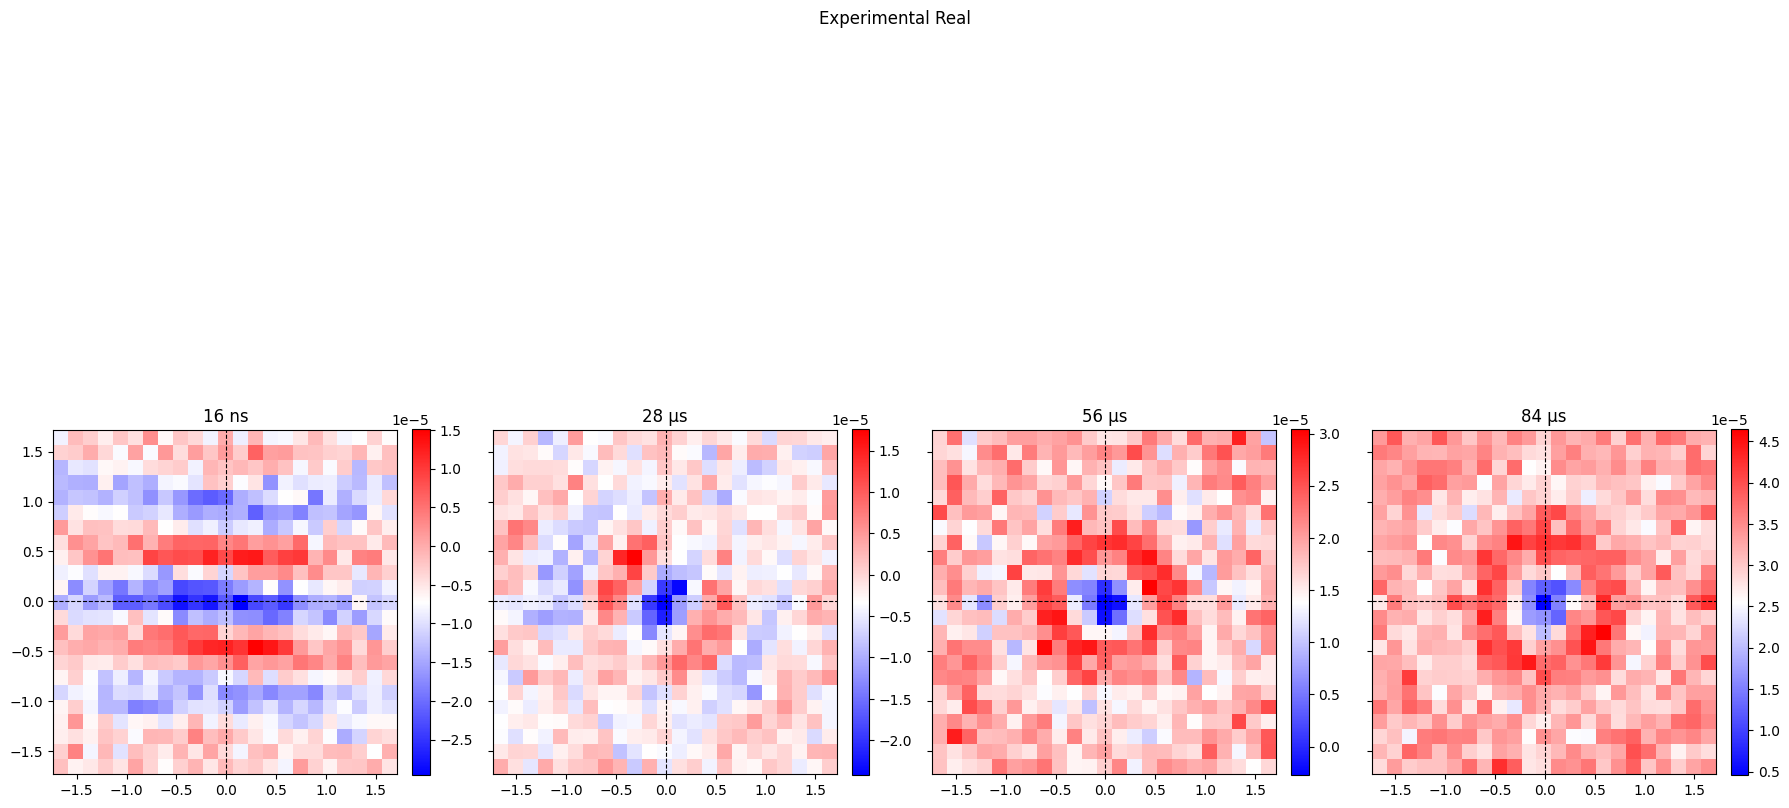

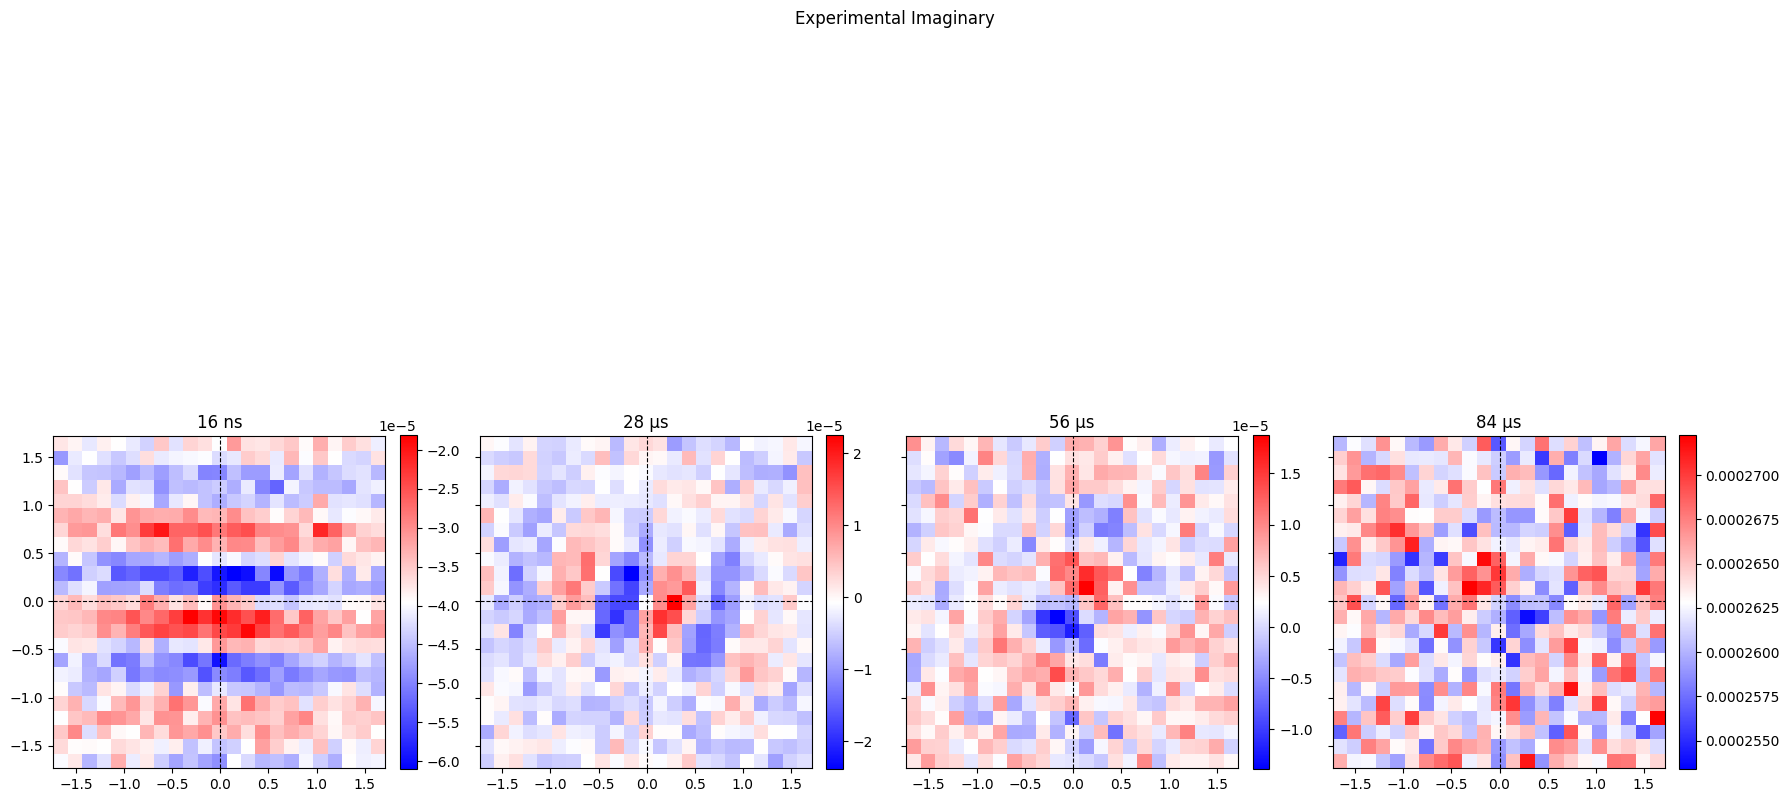

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from helpers.io import load_experiment
from helpers.plotting import plot_characteristic_functions, plot_landscape
from helpers.simulation import CharacteristicFunctionSimulator
from helpers.comparison import build_mask, residue, residue_no_rotation, compare_experiment_simulation, extract_rotation_angles
from helpers.fitting import find_best_alpha
from helpers.optimizer import optimize_parameters
Real_part, Imag_part = True, True
beta_scale, experiment_start = 2.0, '20-01-00'
real_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_1\\data_real' if Real_part else None
imag_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_1\\data_imag' if Imag_part else None
real_decays = np.array([4,7000,14000,21000])*4 if Real_part else None
imag_decays = np.array([4,7000,14000,21000])*4 if Imag_part else None
if not (Real_part or Imag_part): raise ValueError('Select at least one component.')
state_list_real, state_list_imag, x_list, y_list, decay_sweep_sorted = load_experiment(real_dir, imag_dir, real_decays, imag_decays, beta_scale, experiment_start)
exp_data = (state_list_real,state_list_imag) if Real_part and Imag_part else (state_list_real if Real_part else state_list_imag)
if Real_part: plot_characteristic_functions(state_list_real,x_list,y_list,decay_sweep_sorted,'Experimental Real')
if Imag_part: plot_characteristic_functions(state_list_imag,x_list,y_list,decay_sweep_sorted,'Experimental Imaginary')

## 2. Simulation

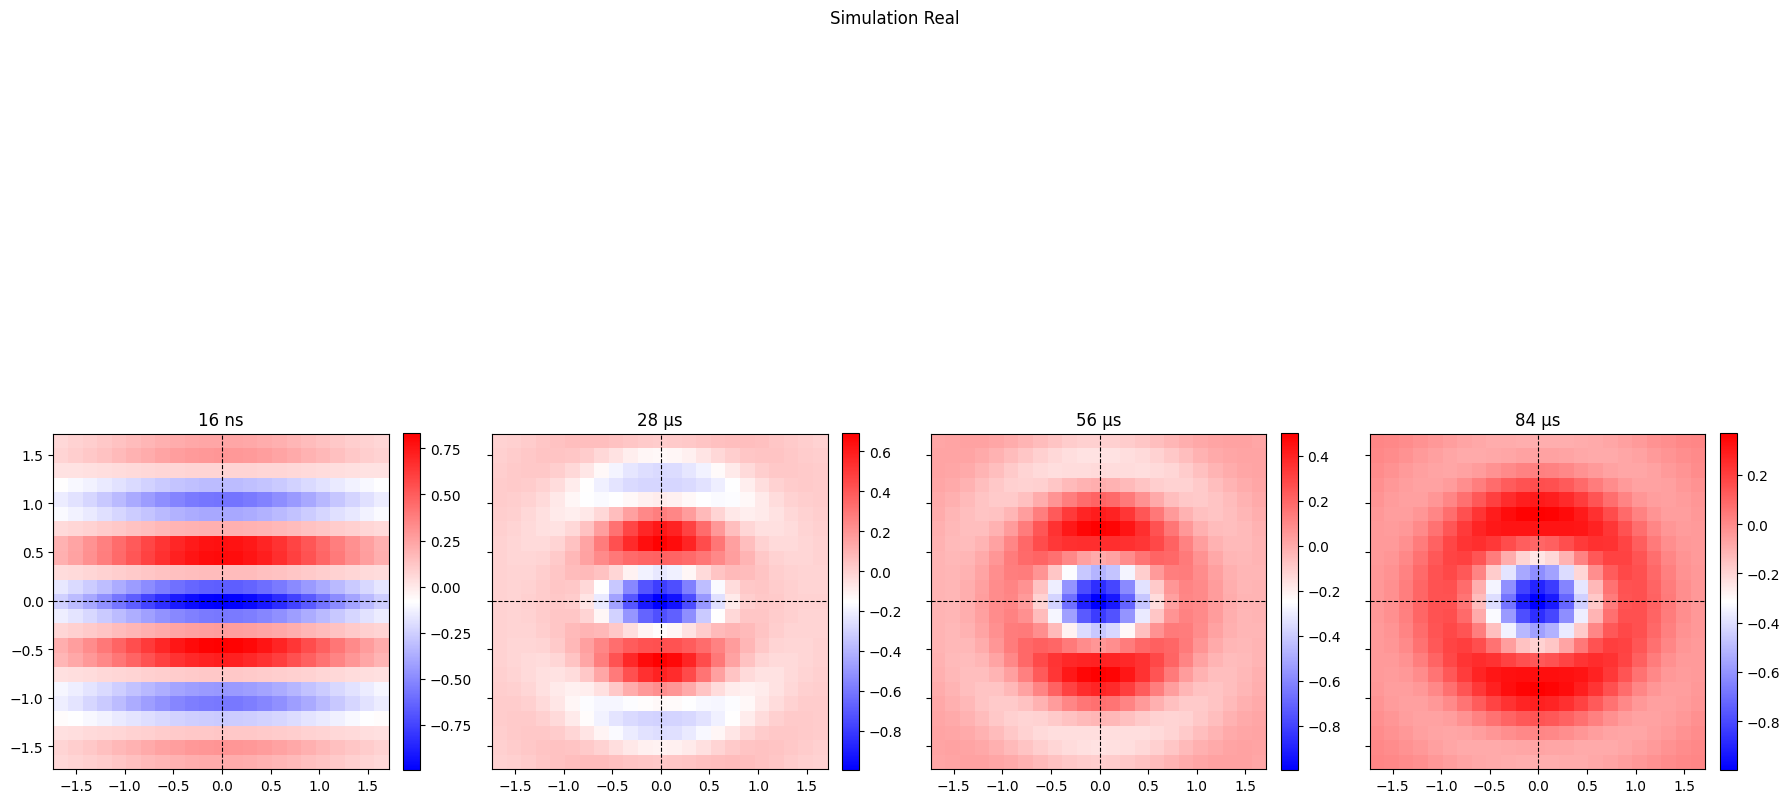

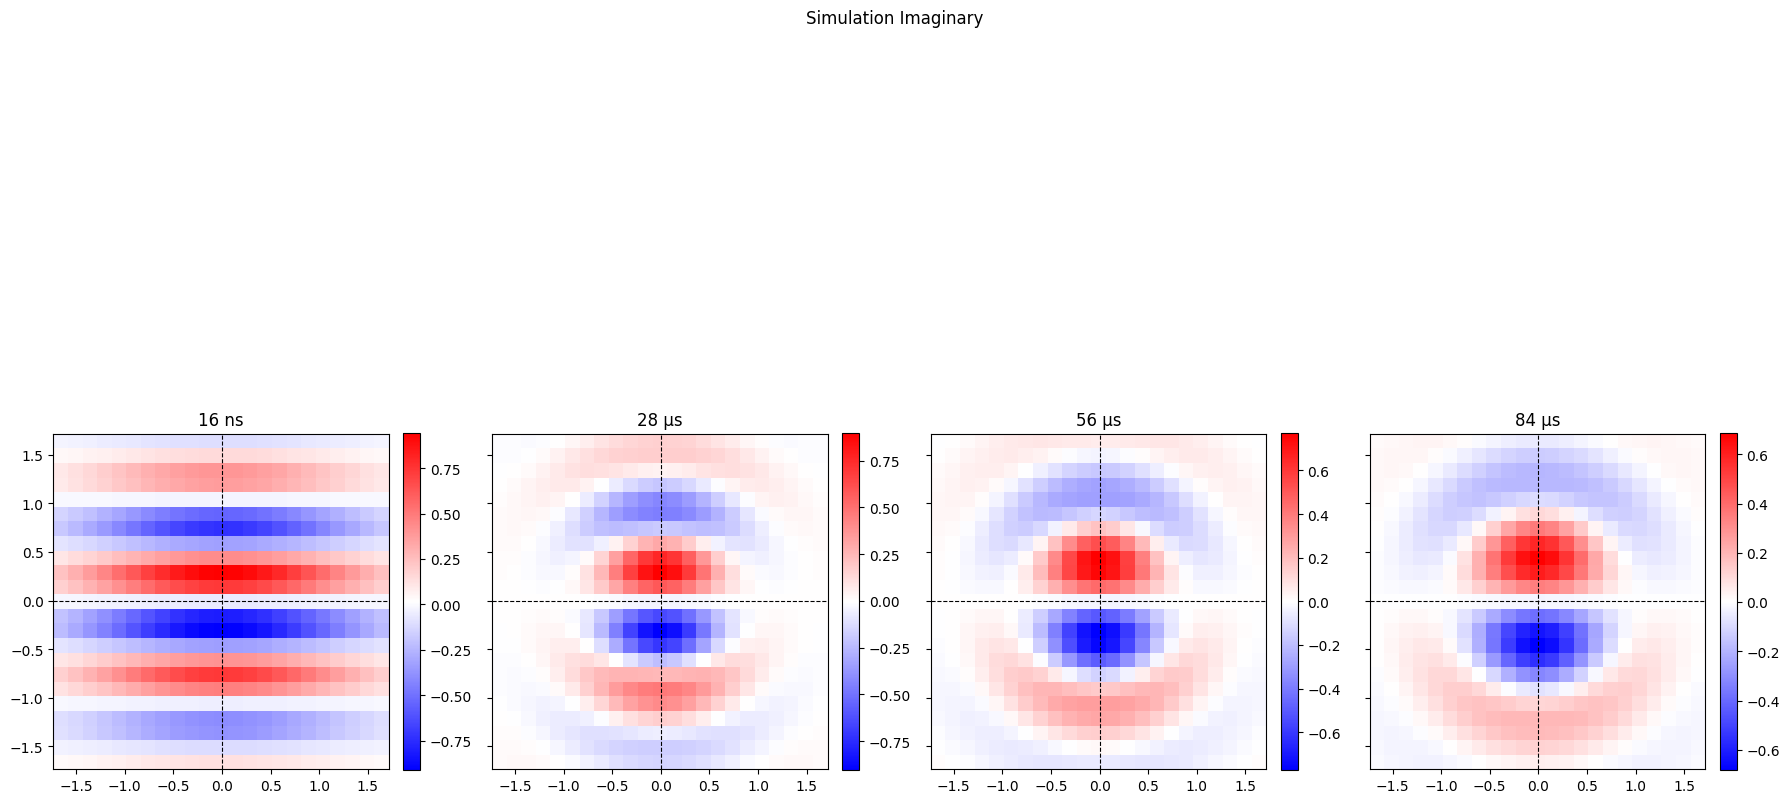

In [20]:
N_c = 50
simulator = CharacteristicFunctionSimulator(N_c,x_list[0],y_list[0])
T1, T2, alpha = 100_000, 100_000, 3.0
charfunc_sim = simulator.simulate(decay_sweep_sorted,T1,T2,alpha=alpha,return_real=Real_part,return_imag=Imag_part)
if Real_part: plot_characteristic_functions(charfunc_sim[0] if Imag_part else charfunc_sim,x_list,y_list,decay_sweep_sorted,'Simulation Real')
if Imag_part: plot_characteristic_functions(charfunc_sim[1] if Real_part else charfunc_sim,x_list,y_list,decay_sweep_sorted,'Simulation Imaginary')

## 3. Fit alpha and rotation

Searching alpha...
alpha=3.2375, angle=4.11 deg, cost=0.372946


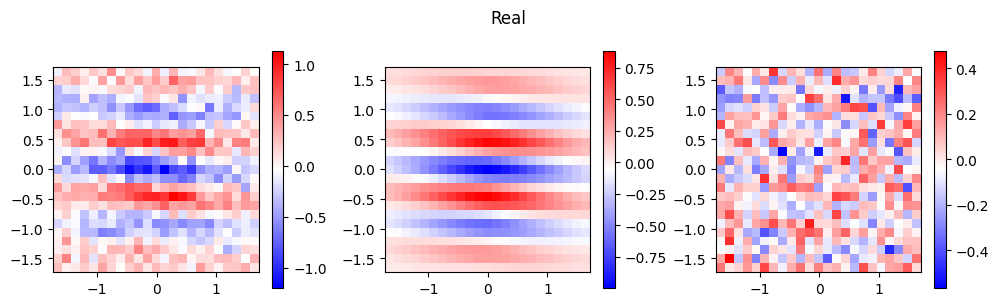

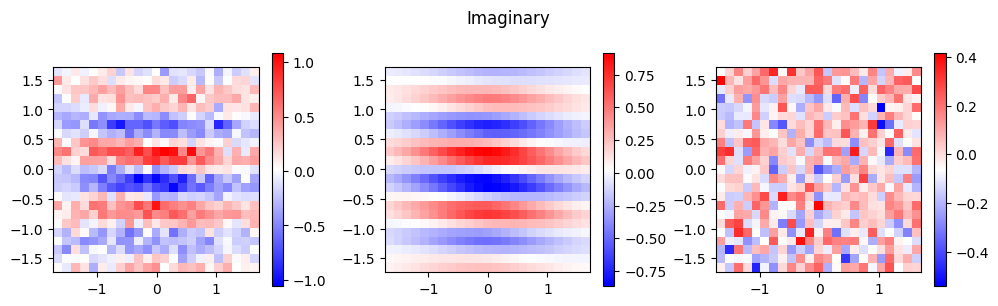

(array([3.33333333]), array([0.8866969]))

In [21]:
mask = build_mask(x_list[0],y_list[0],2.5)
alpha_values = np.linspace(3.0,4.0,81); rotation_values = np.linspace(-10.0,10.0,181)
alpha_fit = find_best_alpha(simulator,exp_data,np.array([decay_sweep_sorted[0]]),alpha_values,rotation_values,mask,component=('real' if Real_part else 'imag'))
initial_alpha, initial_angle = alpha_fit['alpha'], alpha_fit['angle']
print(f'alpha={initial_alpha:.4f}, angle={initial_angle:.2f} deg, cost={alpha_fit["cost"]:.6f}')
alpha_exp_data = (state_list_real[:1], state_list_imag[:1]) if Real_part and Imag_part else (state_list_real[:1] if Real_part else state_list_imag[:1])
compare_experiment_simulation(alpha_exp_data,alpha_fit['sim'],x_list[:1],y_list[:1],mask,rotate_images=True,rotation_angles=rotation_values)

## 4. Coarse T1/T2 grid search

Grid result: T1=550.000 us, T2=125.000 us, residue=0.436766


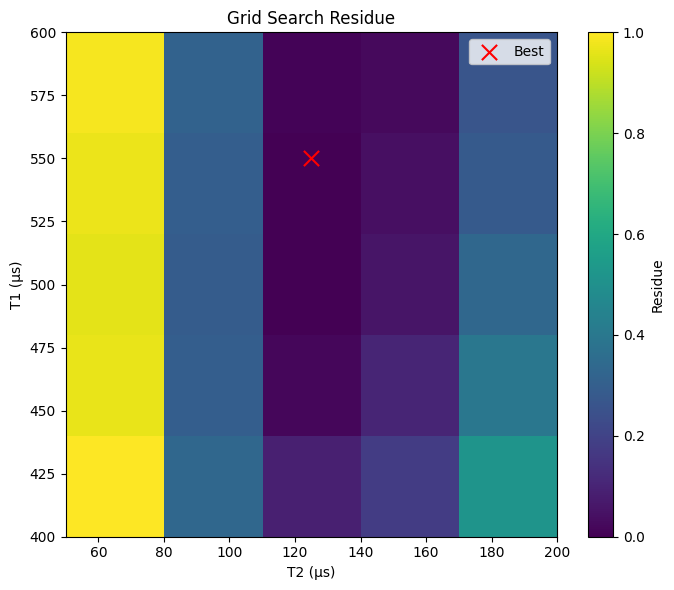

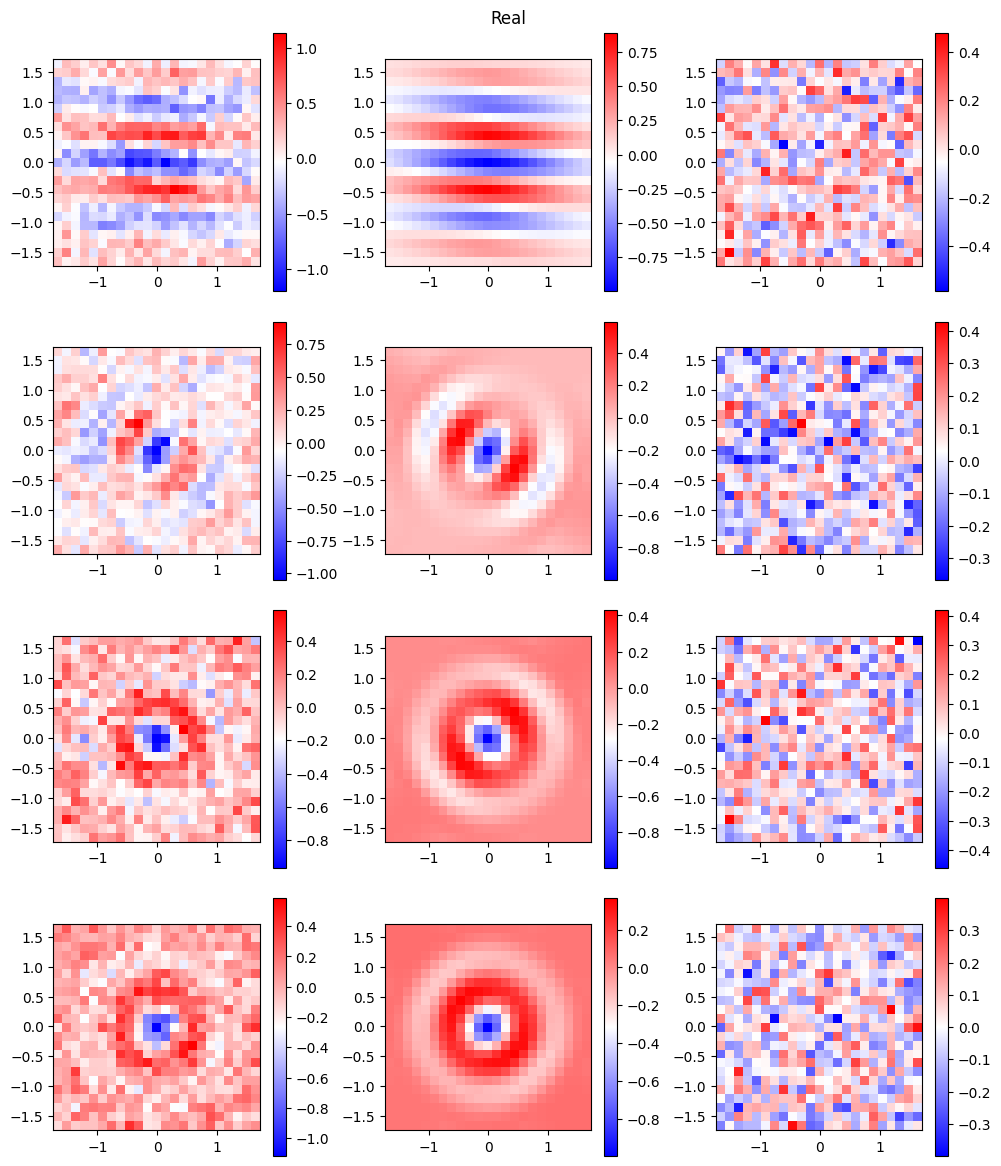

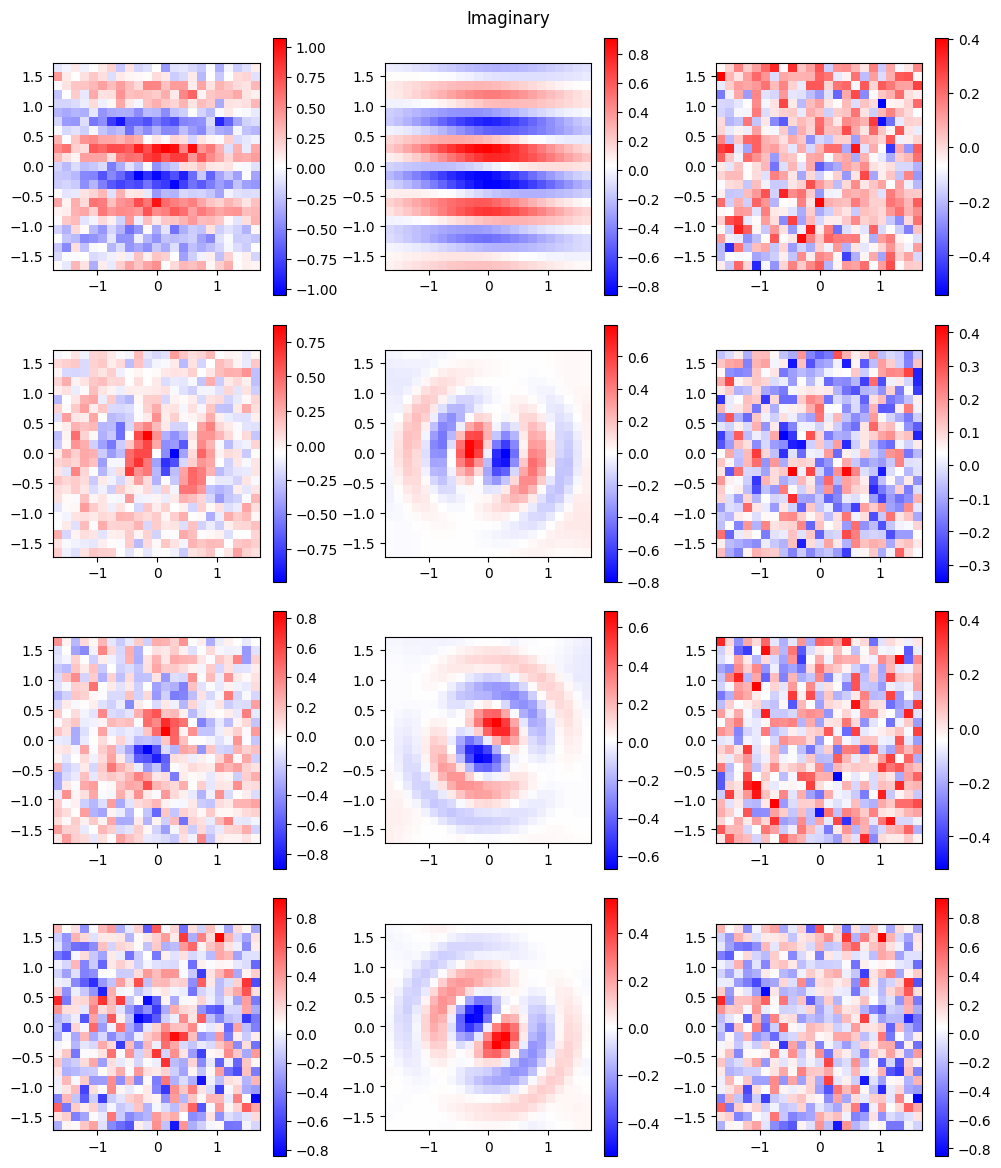

(array([  3., -60.,  30., -44.]),
 array([0.88634324, 0.7504576 , 0.70559   , 0.74537747]))

In [22]:
T1_values=np.linspace(400_000,600_000,5); T2_values=np.linspace(50_000,200_000,5)
cost=np.empty((len(T1_values),len(T2_values)))
for i,t1 in enumerate(T1_values):
    for j,t2 in enumerate(T2_values):
        sim=simulator.simulate(decay_sweep_sorted,t1,t2,alpha=initial_alpha,return_real=Real_part,return_imag=Imag_part)
        cost[i,j]=residue(exp_data,sim,mask)
best=np.unravel_index(np.argmin(cost),cost.shape); best_T1,best_T2=T1_values[best[0]],T2_values[best[1]]
best_sim=simulator.simulate(decay_sweep_sorted,best_T1,best_T2,alpha=initial_alpha,return_real=Real_part,return_imag=Imag_part)
best_angles,best_overlaps=extract_rotation_angles(exp_data,best_sim,mask)
print(f'Grid result: T1={best_T1/1000:.3f} us, T2={best_T2/1000:.3f} us, residue={cost[best]:.6f}')
plot_landscape(cost,T1_values,T2_values,best_T1,best_T2)
compare_experiment_simulation(exp_data,best_sim,x_list,y_list,mask,rotate_images=True)

## 5. Estimate detuning

C:\Users\hecto\AppData\Local\Temp\ipykernel_22856\3522629518.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,_=curve_fit(angle_model,fit_times,fit_angles); initial_angle_offset,initial_detuning=popt[0],popt[1]/360.0


angle offset=3.036 deg, detuning=-0.006254 MHz


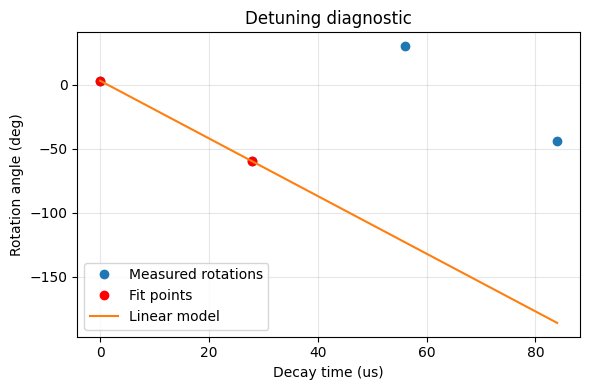

In [23]:
num_points_fit=min(2,len(best_angles)); times_us=np.asarray(decay_sweep_sorted)/1000.0
fit_times,fit_angles=times_us[:num_points_fit],best_angles[:num_points_fit].copy()
for i in range(len(fit_angles)):
    while fit_angles[i]-fit_angles[0]>180: fit_angles[i]-=360
    while fit_angles[i]-fit_angles[0]<-180: fit_angles[i]+=360
def angle_model(t,offset,slope): return offset+slope*t
popt,_=curve_fit(angle_model,fit_times,fit_angles); initial_angle_offset,initial_detuning=popt[0],popt[1]/360.0
print(f'angle offset={initial_angle_offset:.3f} deg, detuning={initial_detuning:.6f} MHz')
plt.figure(figsize=(6,4)); plt.plot(times_us,best_angles,'o',label='Measured rotations'); plt.plot(fit_times,fit_angles,'ro',label='Fit points'); plt.plot(times_us,angle_model(times_us,*popt),'-',label='Linear model'); plt.xlabel('Decay time (us)'); plt.ylabel('Rotation angle (deg)'); plt.title('Detuning diagnostic'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

## 6. Final optimization

Optimizing T1/T2: 100%|██████████| 40/40 [00:22<00:00,  1.79it/s]

Optimization terminated successfully.
         Current function value: 0.444044
         Iterations: 28
         Function evaluations: 53


Final: T1=300.000 us, T2=122.023 us, detuning=-0.007409 MHz, cost=0.444044


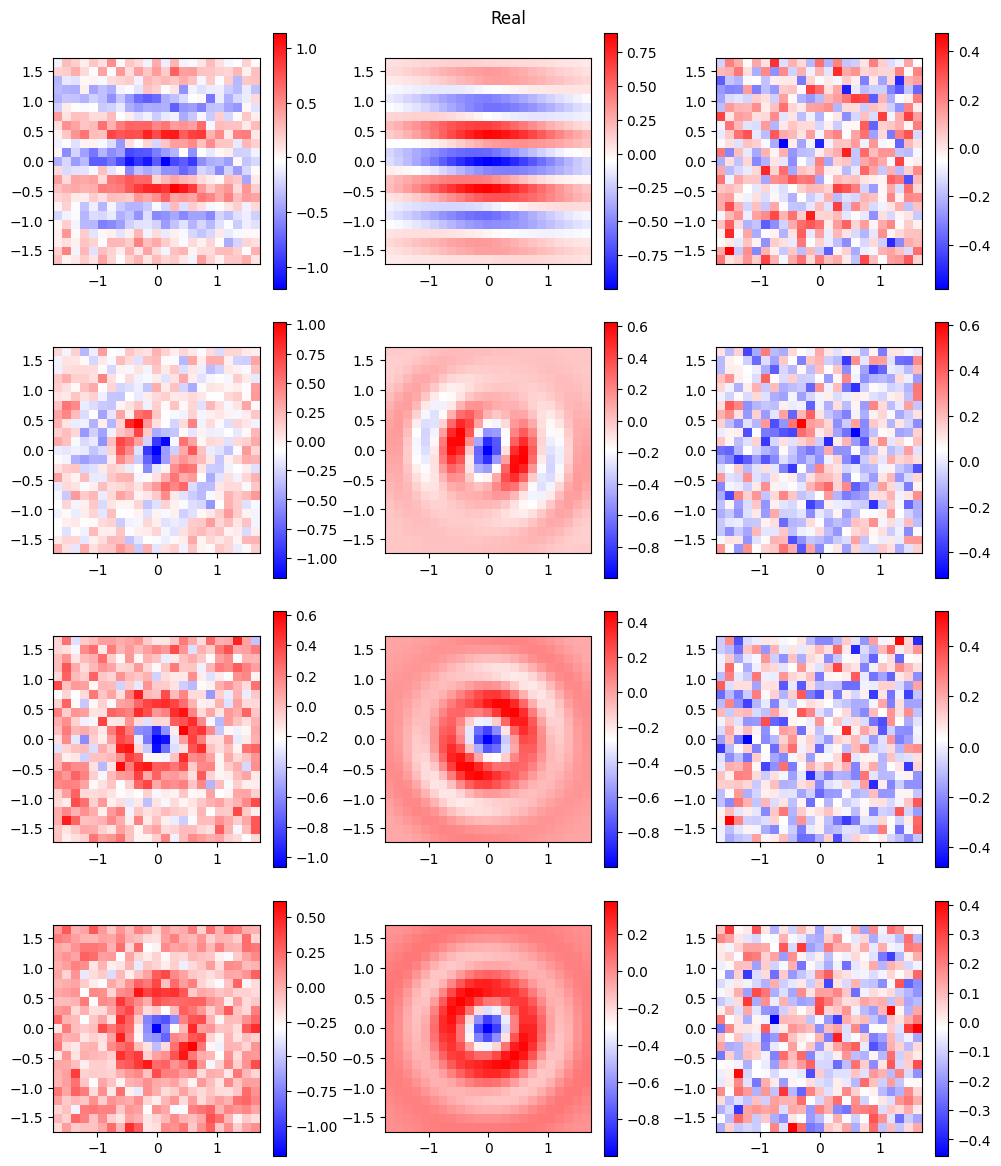

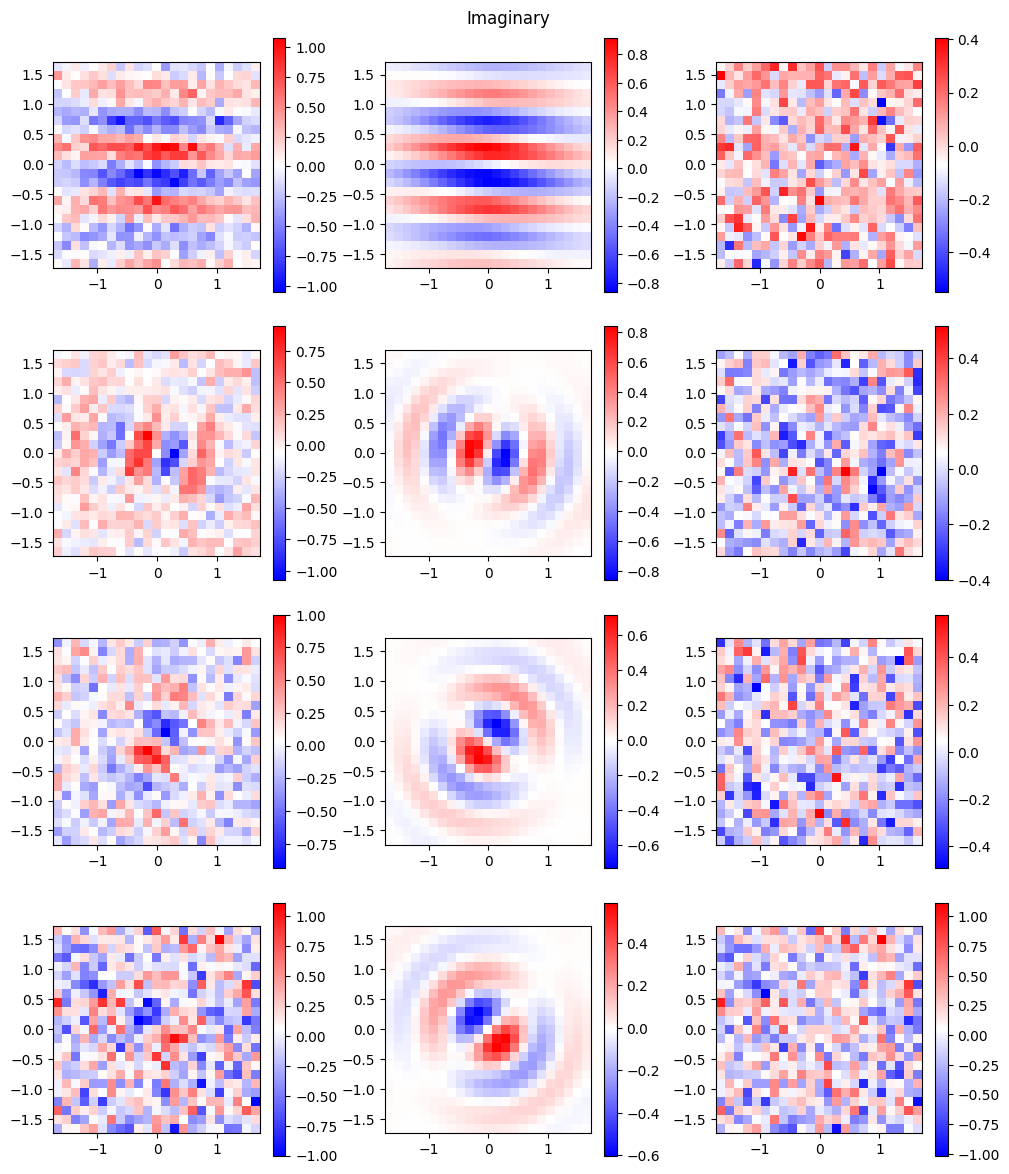

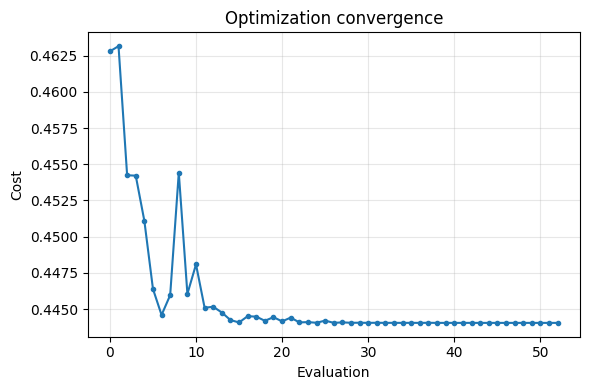

In [24]:
fit_T1=False; fixed_T1=300_000
fit=optimize_parameters(simulator,exp_data,decay_sweep_sorted,best_T1,best_T2,initial_detuning,initial_alpha,initial_angle_offset,lambda e,s,rotate_images=False: residue_no_rotation(e,s,mask),fit_T1=fit_T1,fixed_T1=fixed_T1)
print(f'Final: T1={fit["T1"]/1000:.3f} us, T2={fit["T2"]/1000:.3f} us, detuning={fit["detuning"]:.6f} MHz, cost={fit["cost"]:.6f}')
compare_experiment_simulation(exp_data,fit['simulation'],x_list,y_list,mask,rotate_images=False)
if len(fit['history']):
    plt.figure(figsize=(6,4)); plt.plot(fit['history'][:,3],'-o',ms=3); plt.xlabel('Evaluation'); plt.ylabel('Cost'); plt.title('Optimization convergence'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()